In [1]:
import pandas as pd

# 1. Wczytanie danych
print("Wczytywanie danych...")
df = pd.read_csv('/Users/michalbando/Downloads/Różne/IT/Python/notebooks/IBM_Cognos/survey_data_updated.csv')

# Usuwanie ewentualnych spacji z nazw kolumn
df.columns = df.columns.str.strip()

Wczytywanie danych...


In [2]:
# 2. Czyszczenie danych - używamy ResponseId zamiast Respondent
initial_rows = df.shape[0]
df.drop_duplicates(subset='ResponseId', keep='first', inplace=True)
print(f"Liczba wierszy po usunięciu duplikatów: {df.shape[0]}")

Liczba wierszy po usunięciu duplikatów: 18845


In [3]:
# 3. Lista kolumn dopasowana do Twojego pliku
# Zakładka 1: Aktualne (HaveWorkedWith)
# Zakładka 2: Przyszłe (WantToWorkWith)
tech_columns = [
    'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith',
    'LanguageWantToWorkWith', 'DatabaseWantToWorkWith', 'PlatformWantToWorkWith', 'WebframeWantToWorkWith'
]

all_normalised_data = []

In [ ]:
# 4. Normalizacja (Explode)
for col in tech_columns:
    if col in df.columns:
        # Wybieramy ID i kolumnę, usuwamy puste
        temp_df = df[['ResponseId', col]].dropna()

        # Rozbijamy ciągi (np. "Python;SQL") na osobne wiersze
        temp_df[col] = temp_df[col].astype(str).str.split(';')
        temp_df = temp_df.explode(col)

        # Standaryzacja nazw dla Cognos
        temp_df.rename(columns={col: 'TechnologyValue'}, inplace=True)
        temp_df['TechnologyType'] = col
        all_normalised_data.append(temp_df)


In [ ]:
# 5. Łączenie i dołączanie demografii
if all_normalised_data:
    df_tech_final = pd.concat(all_normalised_data, ignore_index=True)

    # Kolumny demograficzne obecne w Twoim pliku
    # UWAGA: W Twoim pliku nie widzę kolumny 'Gender'. Jeśli jej potrzebujesz,
    # sprawdź czy nie jest w innym pliku lub czy nie nazywa się inaczej.
    base_cols = ['ResponseId', 'Age', 'Country', 'EdLevel', 'RemoteWork']
    available_base = [c for c in base_cols if c in df.columns]

    df_final = pd.merge(df_tech_final, df[available_base], on='ResponseId', how='left')

    # Zapis
    output_filename = 'dashboard_data_final.csv'
    df_final.to_csv(output_filename, index=False)
    print(f"GOTOWE! Utworzono plik: {output_filename}")
else:
    print("Nie znaleziono kolumn technologicznych. Sprawdź nazwy w pliku CSV.")

GOTOWE! Utworzono plik: dashboard_data_final.csv


In [8]:
df_final['TechnologyType'].value_counts()

TechnologyType
LanguageHaveWorkedWith    116557
LanguageWantToWorkWith    106356
WebframeHaveWorkedWith     77803
WebframeWantToWorkWith     71417
DatabaseHaveWorkedWith     69586
DatabaseWantToWorkWith     65913
PlatformHaveWorkedWith     50655
PlatformWantToWorkWith     48410
Name: count, dtype: int64

Wykresy zostały zapisane jako pliki PNG!


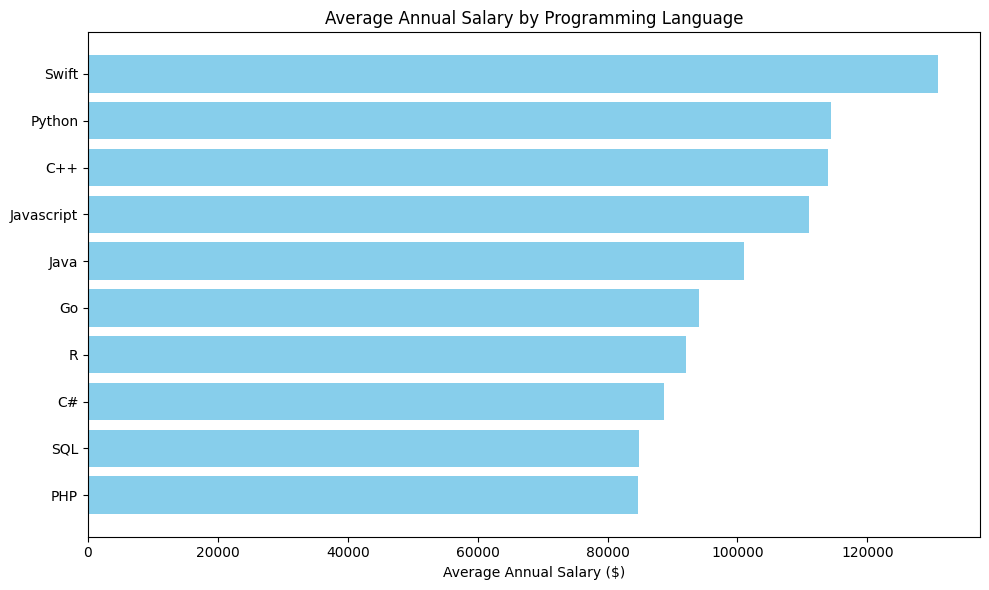

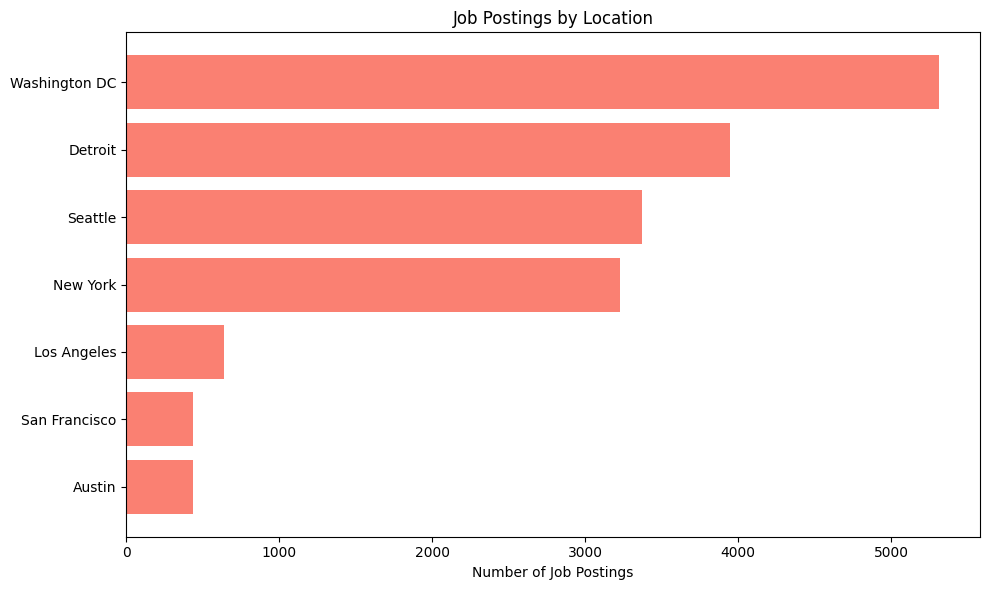

In [9]:


import pandas as pd
import matplotlib.pyplot as plt

# 1. Analiza wynagrodzeń
df_salary = pd.read_csv('/Users/michalbando/Downloads/Różne/IT/Python/data/popular-languages.csv')
# Czyszczenie danych (usuwamy $ i przecinki)
df_salary['Annual Average Salary'] = df_salary['Annual Average Salary'].str.replace('$', '').str.replace(',', '').astype(float)
df_salary = df_salary.sort_values(by='Annual Average Salary', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_salary['Language Name'], df_salary['Annual Average Salary'], color='skyblue')
plt.xlabel('Average Annual Salary ($)')
plt.title('Average Annual Salary by Programming Language')
plt.tight_layout()
plt.savefig('salary_analysis.png') # Plik do wklejenia do PPT

# 2. Analiza rynku pracy
df_jobs = pd.read_excel('/Users/michalbando/Downloads/Różne/IT/Python/data/job-postings.xlsx')
df_jobs = df_jobs.sort_values(by='Number of Jobs', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_jobs['Location'], df_jobs['Number of Jobs'], color='salmon')
plt.xlabel('Number of Job Postings')
plt.title('Job Postings by Location')
plt.tight_layout()
plt.savefig('job_postings_analysis.png') # Drugi plik do PPT

print("Wykresy zostały zapisane jako pliki PNG!")